In [7]:
import numpy as np
import h5py
import matplotlib.pyplot as plt


import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (8,6)
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['axes.grid'] = True
mpl.rcParams['axes.grid.which'] = 'both'
mpl.rcParams['grid.color'] = 'grey'
mpl.rcParams['grid.alpha'] = 0.2
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['axes.labelsize'] = 22
mpl.rcParams['legend.handlelength'] = 3
mpl.rcParams['legend.fontsize'] = 20
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True      # show ticks on the top axis
mpl.rcParams['ytick.right'] = True    # show ticks on the right axis

from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

In [ ]:
from scipy.stats import truncnorm

def sample_gaussian_component_spins(n_samples, mu_a, sigma_a, mu_t, sigma_t, zeta):
    """
    Samples spin magnitudes and tilts for a BBH population.
    """
    # 1. Sample spin magnitudes (Truncated between 0 and 1)
    # scipy's truncnorm expects bounds defined in terms of standard deviations
    a_lower = (0.0 - mu_a) / sigma_a
    a_upper = (1.0 - mu_a) / sigma_a
    a_samples = truncnorm.rvs(a_lower, a_upper, loc=mu_a, scale=sigma_a, size=n_samples)

    # 2. Sample cosine tilts (Mixture of Truncated Normal and Uniform between -1 and 1)
    # Generate a boolean mask to determine which samples come from the Gaussian component
    is_gaussian = np.random.binomial(1, zeta, size=n_samples).astype(bool)
    
    cost_samples = np.empty(n_samples)

    # Populate Gaussian component
    n_gaussian = np.sum(is_gaussian)
    if n_gaussian > 0:
        t_lower = (-1.0 - mu_t) / sigma_t
        t_upper = (1.0 - mu_t) / sigma_t
        cost_samples[is_gaussian] = truncnorm.rvs(t_lower, t_upper, loc=mu_t, scale=sigma_t, size=n_gaussian)

    # Populate Uniform component
    n_uniform = n_samples - n_gaussian
    if n_uniform > 0:
        cost_samples[~is_gaussian] = np.random.uniform(-1.0, 1.0, size=n_uniform)

    return a_samples, cost_samples

# Example usage for a catalog of 10,000 black holes
n_bh = 10000
a, cost = sample_gaussian_component_spins(
    n_samples=n_bh, 
    mu_a=0.2, sigma_a=0.1, 
    mu_t=0.5, sigma_t=0.4, 
    zeta=0.7
)

In [2]:
def sample_gaussian_component_spins_binary(n_binaries, mu_a, sigma_a, mu_t, sigma_t, zeta):
    """
    Samples spin magnitudes and tilts for n_binaries (yielding 2 * n_binaries black holes).
    Returns arrays of shape (n_binaries, 2) for both magnitudes and tilts.
    """
    # Sample 2 * n_binaries independent spins from the marginals
    a_samples, cost_samples = sample_gaussian_component_spins(
        n_samples=n_binaries * 2, 
        mu_a=mu_a, sigma_a=sigma_a, 
        mu_t=mu_t, sigma_t=sigma_t, 
        zeta=zeta
    )
    
    # Reshape into pairs (primary, secondary)
    # Conditional on the hyperparameters, a1 and a2 are independent
    a_binary = a_samples.reshape(n_binaries, 2)
    cost_binary = cost_samples.reshape(n_binaries, 2)
    
    return a_binary, cost_binary

In [14]:
mu_chi      =  0.103545
sigma_chi   =  0.339752
mu_spin       =  0.228621
sigma_spin    =  0.530840
xi_spin       =  0.940896

In [15]:
chis, costs = sample_gaussian_component_spins_binary(
    n_binaries=100000,
    mu_a=mu_chi, sigma_a=sigma_chi,
    mu_t=mu_spin, sigma_t=sigma_spin,
    zeta=xi_spin
)

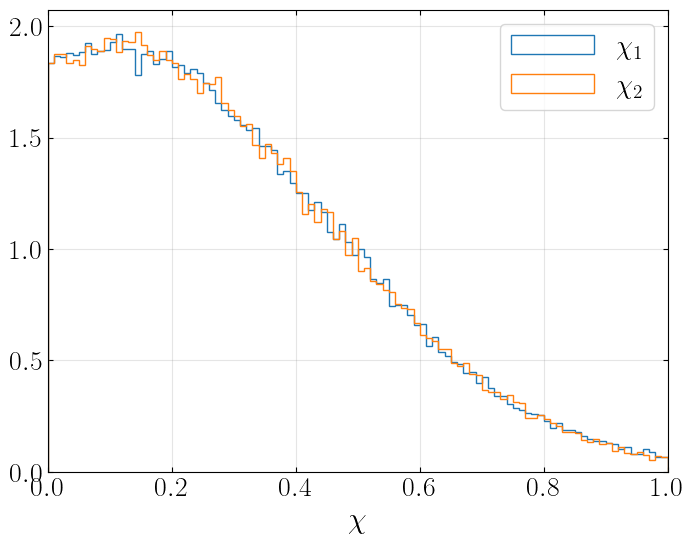

In [16]:
plt.hist(chis[:,0], bins=100, density=True, histtype='step', label=r'$\chi_1$')
plt.hist(chis[:,1], bins=100, density=True, histtype='step', label=r'$\chi_2$')
plt.xlabel(r'$\chi$')
plt.xlim(0.,1.)
plt.legend()
plt.savefig('spin_magnitudes.png', dpi=300)

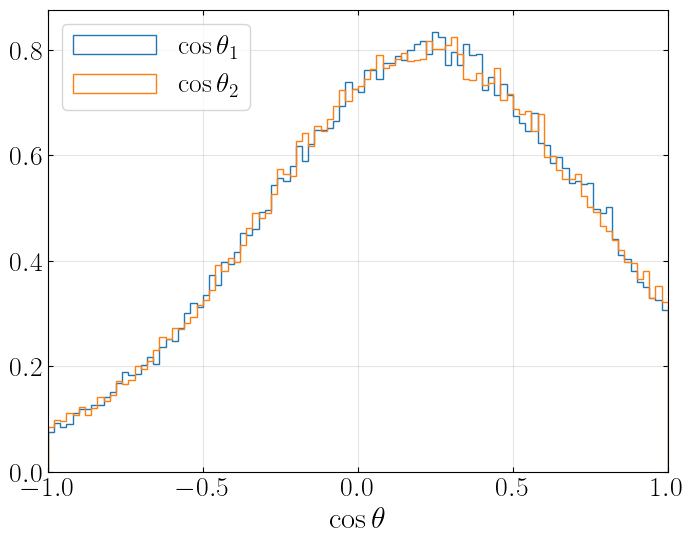

In [17]:
plt.hist(costs[:,0], bins=100, density=True, histtype='step', label=r'$\cos\theta_1$')
plt.hist(costs[:,1], bins=100, density=True, histtype='step', label=r'$\cos\theta_2$')
plt.xlabel(r'$\cos\theta$')
plt.xlim(-1.,1.)
plt.legend()
plt.savefig('spin_tilts.png', dpi=300)